In [1]:
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt 
import matplotlib.patches as patches
from scipy import special 

# Monte Carlo Integration 

Monte Carlo Integration is a way to solve integrals using random numbers. 

## Example: Area of circle

One can use this to determine $\pi$. See https://en.wikipedia.org/wiki/Monte_Carlo_integration . 

Consider the function  $H\left(x,y\right)={\begin{cases}1&{\text{if }}x^{2}+y^{2}\leq 1\\0&{\text{else}}\end{cases}}$ and the parameter space $Ω = [−1,1] × [−1,1]$ with Area = $4$. Then 

$I_{\pi }=\int _{\Omega }H(x,y)dxdy=\pi \quad .$

Thus, a crude way of calculating the value of π with Monte Carlo integration is to pick $N$ random numbers on Ω and compute

$Q_{N}=4{\frac {1}{N}}\sum _{i=1}^{N}H(x_{i},y_{i})$


In [2]:
rng = np.random.default_rng(42)

def determine_area_circle(throws,radius):
    # Choose random X and Y data centered around 0,0
    x = rng.uniform(-radius, radius, throws)
    y = rng.uniform(-radius, radius, throws)
    
    # Count the times (x, y) is inside the circle,
    # which happens when sqrt(x^2 + y^2) <= radius.
    inside_circle = np.count_nonzero(np.hypot(x, y) <= radius)
    
    # Calculate area and print; should be closer to Pi with increasing number of throws, if radius is 1
    area = (2 * radius)**2 * inside_circle / throws
    return area


In [3]:
a_10 = determine_area_circle(10,1) 
a_100 = determine_area_circle(100,1) 
a_1000 = determine_area_circle(1000,1) 
a_10000 = determine_area_circle(10000,1) 
print(a_10,a_100,a_1000,a_10000)

3.2 3.12 3.064 3.1348


## Visualization

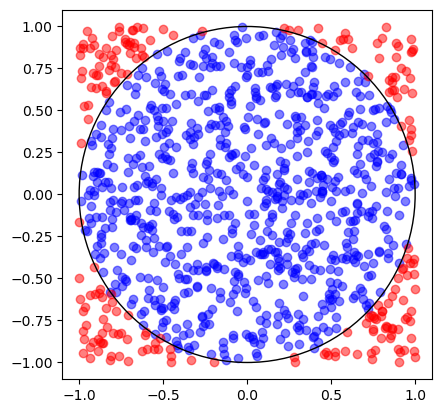

In [5]:
throws=1000
radius = 1.0
x = rng.uniform(-radius, radius, throws)
y = rng.uniform(-radius, radius, throws)
insideX,  insideY  = x[(x*x+y*y)<=1],y[(x*x+y*y)<=1]
outsideX, outsideY = x[(x*x+y*y)>1],y[(x*x+y*y)>1]

fig, ax = plt.subplots(1,1)
ax.scatter(insideX, insideY, c='b', alpha=0.5)
ax.scatter(outsideX, outsideY, c='r', alpha=0.5)
ax.set_aspect('equal')
circle = patches.Circle((0.0, 0.0), 1.0, facecolor='none', edgecolor='black')

# Add the circle to the axes
ax.add_patch(circle)

plt.show()

In [5]:
throws =  np.geomspace(1, 1e8, num=8)
results = []
relative_error = [] 
for i,t in enumerate(throws): 
    a = determine_area_circle(int(t),1) 
    results.append(a)
    relative_error.append((a-np.pi)/np.pi)

print(results)

[4.0, 3.3846153846153846, 3.2124352331606216, 3.1558538404175986, 3.1362575452716297, 3.143503099738004, 3.140970445983635, 3.1415284]


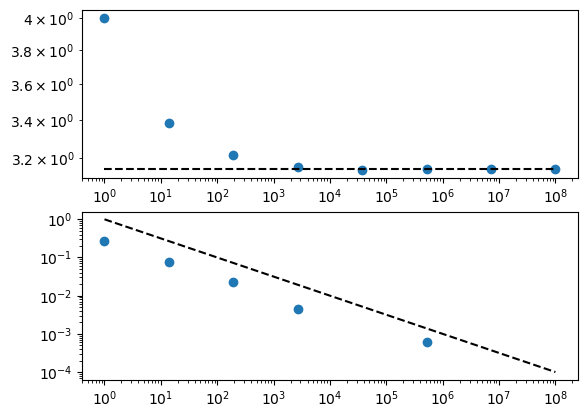

In [6]:
fig, ax = plt.subplots(2,1)

ax[0].scatter(throws,results)
ax[1].scatter(throws,relative_error)
ax[0].plot(throws,np.ones(shape=len(throws))*np.pi,c='black',linestyle='dashed')
ax[1].plot(throws,1.0/np.sqrt(throws),c='black',linestyle='dashed')
ax[0].set_xscale('log')
ax[1].set_xscale('log') 
ax[0].set_yscale('log')
ax[1].set_yscale('log') 

plt.show()

## More challenging example 

Let's find the probability that a randomly chosen variable $X$ from the standard normal distribution is greater than 3. We know that one way to solve this is by solving the following integral:

$$
P(X>3)=\int_3^{\infty} f_X(t) d t=\frac{1}{\sqrt{2 \pi}} \int_3^{\infty} e^{-t^2 / 2} d t
$$

If we define the function $h: \mathbb{R} \rightarrow \mathbb{R}$ as
$$
h(t)= \begin{cases}1 & \text { if } t>3 \\ 0 & \text { if } t \leq 3\end{cases}
$$
we can rewrite this integral as
$$
\int_3^{\infty} f_X(t) d t=\int_{-\infty}^{\infty} h(t) f_X(t) d t
$$

Then, we can say
$$
\int_{-\infty}^{\infty} h(t) f_X(t) d t=E[h(X)]
$$
by being able to write integrals as expected values. We can now easily estimate this same probabilty using Monte Carlo simulation. Given a random sample $x_1, x_2, \cdots, x_N$ generated by $f_X$ (in this case a Gaussian distribution!), we can estimate $E[h(X)]$ using
$$
\widehat{E}_n[h(X)]=\frac{1}{N} \sum_{i=1}^N h\left(x_i\right)
$$
Now that we have defined the estimator, it is now quite manageable to approximate the solution. 


The analytical answer can be found as: 
$P(X>3)=\frac{1}{2}\cdot \mathrm{erfc}\left(\frac{3}{\sqrt{2}}\right) =0.0013498980316300959 $

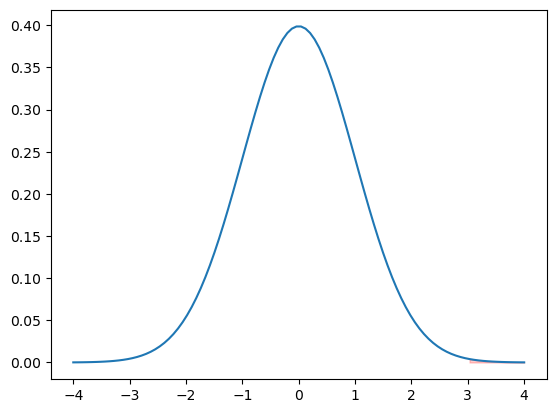

In [21]:
fig, ax = plt.subplots(1,1) 

x = np.linspace(-4,4,100)
f = 1/np.sqrt(2*np.pi)*np.exp(-x**2/2)
ax.plot(x,f)
plt.fill_between(x= x, y1= f, 
        where= (3 < x),
        color= "r",
        alpha= 0.2)
plt.show()

In [60]:
rng = np.random.default_rng(42)

def determine_prob_three(throws):
    
    x = rng.normal(size=throws)
    inside_area = np.count_nonzero(x > 3)

    result = inside_area/throws
    return result

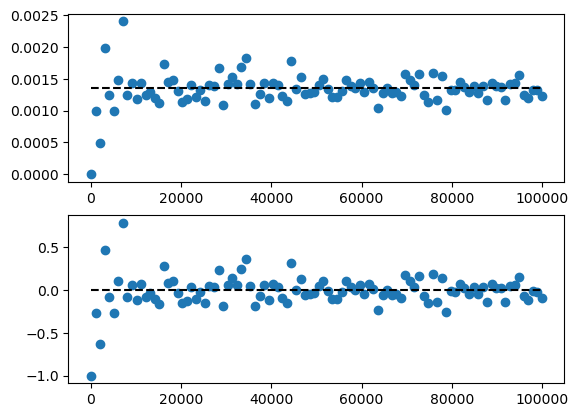

In [68]:
analytical_answer = 1/2*special.erfc(3/np.sqrt(2))

throws =  np.linspace(1,100000,num=100)
results = []
relative_error = [] 
for i,t in enumerate(throws): 
    a = determine_prob_three(int(t))
    results.append(a)
    relative_error.append((a-analytical_answer)/analytical_answer)

fig, ax = plt.subplots(2,1)

ax[0].scatter(throws,results)
ax[1].scatter(throws,relative_error)
ax[0].plot(throws,np.ones(shape=len(throws))*analytical_answer,c='black',linestyle='dashed')
ax[1].plot(throws,np.zeros(shape=len(throws)),c='black',linestyle='dashed')

plt.show()


This is really not that efficient! 

**Importance sampling** is one way to make Monte Carlo simulations converge much faster. We choose a different distribution to sample our points to generate more *important points*. With our example, we want to choose a distribution that would generate more numbers around 3 to get a more reliable estimate. The theory behind importance sampling boils down to the following result. In these equations, the random variable $X$ is generated by $f_X$ and the random variable $Y$ is generated by $g_Y$:

\begin{align}
E[h(X)] =& =\int_{-\infty}^{\infty} h(t) f_X(t) d t \\
& =\int_{-\infty}^{\infty} h(t) f_X(t)\left(\frac{g_Y(t)}{g_Y(t)}\right) d t \\
& =\int_{-\infty}^{\infty}\left(\frac{h(t) f_X(t)}{g_Y(t)}\right) g_Y(t) d t \\
& =E\left[\frac{h(Y) f_X(Y)}{g_Y(Y)}\right]
\end{align}

The corresponding estimator is
$$
\begin{aligned}
\widehat{E}[h(X)] & =\widehat{E}\left[\frac{h(Y) f_X(Y)}{g_Y(Y)}\right] \\
& =\frac{1}{N} \sum_{i=1}^N \frac{h\left(y_i\right) f_X\left(y_i\right)}{g_Y\left(y_i\right)}
\end{aligned}
$$

The function $f_X$ is the p.d.f. of the target distribution. The function $g_Y$ is the p.d.f. of the importance distribution. The fraction $\frac{f_X(X)}{g_Y(X)}$ is called the importance weight. This allows us to draw a sample from any distribution with p.d.f. $g_Y$ as long as we multiply $h(X)$ by the importance weight.

Now we need to choose $g_Y$  - often, a reasonable guess is good enough. 

In [75]:

def determine_prob_three_importance_sampling(throws):
    
    x = rng.normal(size=throws,loc=4,scale=1)
    importance_weight = (1/np.sqrt(2*np.pi)*np.exp(-x**2/2))/(1/np.sqrt(2*np.pi)*np.exp(-(x-4.0)**2/2))
    result = np.sum((x>3)*importance_weight)/throws
    
    return result

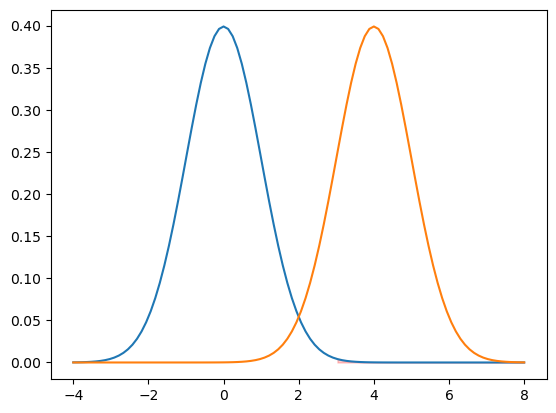

In [81]:
fig, ax = plt.subplots(1,1) 

x = np.linspace(-4,8,100)
f = 1/np.sqrt(2*np.pi)*np.exp(-x**2/2)
f2 = 1/np.sqrt(2*np.pi)*np.exp(-(x-4)**2/2)
ax.plot(x,f)
ax.plot(x,f2)
plt.fill_between(x= x, y1= f, 
        where= (3 < x),
        color= "r",
        alpha= 0.2)
plt.show()

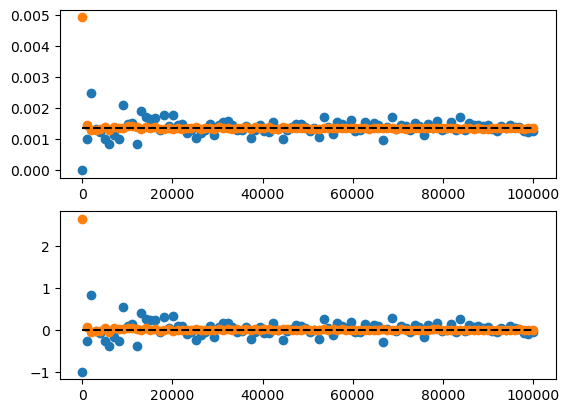

In [78]:
throws =  np.linspace(1,100000,num=100)
results_direct = []
results_important = []
relative_error_direct = [] 
relative_error_important = [] 
for i,t in enumerate(throws): 
    a = determine_prob_three(int(t))
    b = determine_prob_three_importance_sampling(int(t))
    results_direct.append(a)
    results_important.append(b)
    relative_error_direct.append((a-analytical_answer)/analytical_answer)
    relative_error_important.append((b-analytical_answer)/analytical_answer)

fig, ax = plt.subplots(2,1)

ax[0].scatter(throws,results_direct)
ax[0].scatter(throws,results_important)
ax[1].scatter(throws,relative_error_direct)
ax[1].scatter(throws,relative_error_important)
ax[0].plot(throws,np.ones(shape=len(throws))*analytical_answer,c='black',linestyle='dashed')
ax[1].plot(throws,np.zeros(shape=len(throws)),c='black',linestyle='dashed')

plt.show()
